In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

## Victor's QICK-DAWG Notebook
For single NVs (with SILs) - done by hand (Irrelevant to QICK)

In [76]:
power_v_counts = {1012.0: 291000,
 781.0: 277000,
 580.0: 254000,
 503.0: 242000,
 410.0: 226000,
 351.0: 214000,
 275.0: 190000,
 250.0: 183000,
 235.0: 174000,
 225.0: 170000,
 209.0: 164000,
 183.0: 152000,
 174.4: 149000,
 150.1: 133000,
 139.4: 128000,
 131.3: 121000,
 114.5: 111000,
 95.8: 98000,
 89.2: 88500,
 70.3: 74600,
 56.1: 61700,
 43.4: 48800,
 32.3: 38500,
 23.3: 28400,
 20.1: 24500,
 14.7: 18800,
 10.7: 13600,
 5.2: 7000,
 1.9: 3000,
 0.8: 1500,
 0.0: 500}

P = sorted(power_v_counts.keys())
I = [power_v_counts[val] for val in P]

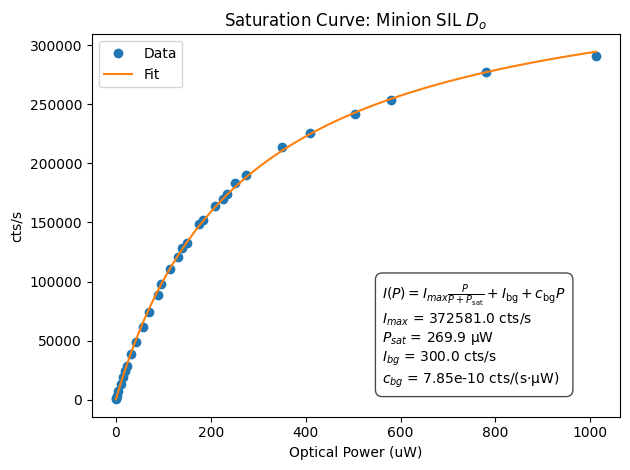

In [154]:
# plot the data points
plt.plot(P, I, marker='o', linestyle='', label='Data')
plt.xlabel('Optical Power (uW)')
plt.ylabel('cts/s')
plt.title(r'Saturation Curve: Minion SIL $\mathit{D_o}$')

# Add fit
def saturation_curve(P, I_sat, P_sat, I_bg, c):
    return I_sat * P / (P + P_sat) + I_bg + c * P

params, cov = curve_fit(
    saturation_curve, P, I, p0=[200000, 100, 500, 0],
    bounds=([0, 0, 300, 0], [np.inf, np.inf, 1000, np.inf]),
)

P_fit = np.linspace(0, max(P), 1000)
plt.plot(P_fit, saturation_curve(P_fit, *params), '-', label="Fit")
plt.legend()

textstr = (
    r"$I(P) = I_{max}\frac{P}{P + P_{\rm sat}} + I_{\rm bg} + c_{\rm bg}P$" + "\n"
    + r"$I_{max}$" + f" = {params[0]:.1f} cts/s\n"
    + r"$P_{sat}$" + f" = {params[1]:.1f} µW\n"
    + r"$I_{bg}$" + f" = {params[2]:.1f} cts/s\n"
    + r"$c_{bg}$" + f" = {params[3]:.2e} cts/(s·µW)"
)

plt.text(
    0.55, 0.35, textstr,
    transform=plt.gca().transAxes,   # place relative to axes
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)

plt.tight_layout()
plt.show()